In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.19.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



# **Importing and Downloading the Dataset** 
https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


In [4]:
import kagglehub
import os

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)

# See what's inside
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 3:
        print(f"{indent}  ... {len(files)} files")

Dataset path: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
chest-xray-pneumonia/
  chest_xray/
    chest_xray/
      val/
        ... 1 files
        PNEUMONIA/
        NORMAL/
      test/
        ... 1 files
        PNEUMONIA/
        NORMAL/
      train/
        ... 1 files
        PNEUMONIA/
        NORMAL/
    __MACOSX/
      chest_xray/
        ... 3 files
        val/
          PNEUMONIA/
          NORMAL/
        test/
          PNEUMONIA/
          NORMAL/
        train/
          PNEUMONIA/
          NORMAL/
    val/
      PNEUMONIA/
        ... 8 files
      NORMAL/
        ... 8 files
    test/
      PNEUMONIA/
        ... 390 files
      NORMAL/
        ... 234 files
    train/
      PNEUMONIA/
        ... 3875 files
      NORMAL/
        ... 1341 files


# **Setting Path & Loading Data**

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Set your dataset paths
train_dir = os.path.join(path, "chest_xray", "train")
val_dir   = os.path.join(path, "chest_xray", "val")
test_dir  = os.path.join(path, "chest_xray", "test")

print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))

Train classes: ['PNEUMONIA', 'NORMAL']
Test classes: ['PNEUMONIA', 'NORMAL']


# **Creating Data Generation**

In [6]:
IMG_SIZE = (224, 224)
BATCH = 32

# Augment training data slightly,
train_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

plain_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical'
)

# Val set is tiny (only 16 images)
val_data = plain_gen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical'
)

test_data = plain_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False   
)

NUM_CLASSES = train_data.num_classes
print(f"\nClasses: {train_data.class_indices}")
print(f"Train samples: {train_data.samples}")
print(f"Val samples:   {val_data.samples}")
print(f"Test samples:  {test_data.samples}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Train samples: 5216
Val samples:   16
Test samples:  624



# **Building VGG-19 from Scratch**

In [8]:
def build_vgg19(num_classes):
    model = models.Sequential()

    # Input
    model.add(layers.InputLayer(shape=(224, 224, 3)))

    # Block 1
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

    # Block 2
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

    # Block 3
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

    # Block 4
    model.add(layers.Conv2D(512, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(512, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(512, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(512, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

    # Block 5
    model.add(layers.Conv2D(512, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(512, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(512, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(512, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

    # Flatten + Fully Connected
    model.add(layers.Flatten())
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


vgg19 = build_vgg19(NUM_CLASSES)
vgg19.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,31

 Total params: 139,578,434 (532.45 MB)

 Trainable params: 139,578,434 (532.45 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
import warnings
warnings.filterwarnings('ignore')

# **Training VGG-19**

In [12]:
vgg19.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = vgg19.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10


I0000 00:00:1777876212.750042     171 service.cc:152] XLA service 0x7e43fc0025d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777876212.750081     171 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777876213.889070     171 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777876235.226547     171 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 153s 770ms/step - accuracy: 0.7357 - loss: 0.6082 - val_accuracy: 0.5000 - val_loss: 0.8177
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 577ms/step - accuracy: 0.7651 - loss: 0.4875 - val_accuracy: 0.7500 - val_loss: 0.5530
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 583ms/step - accuracy: 0.8582 - loss: 0.3403 - val_accuracy: 0.6250 - val_loss: 0.4528
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 585ms/step - accuracy: 0.9053 - loss: 0.2378 - val_accuracy: 0.6875 - val_loss: 0.6587
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 585ms/step - accuracy: 0.9315 - loss: 0.1760 - val_accuracy: 0.6250 - val_loss: 0.9229
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 98s 597ms/step - accuracy: 0.9389 - loss: 0.1623 - val_accuracy: 0.8125 - val_loss: 0.6029
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 588ms/step - accuracy: 0.9466 - loss: 0.1301 - val_accuracy: 0.7500 - val_loss: 0.6163
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 590ms/step - accuracy: 0.9586 - loss: 0.1196 - va



# **Plotting The Results**

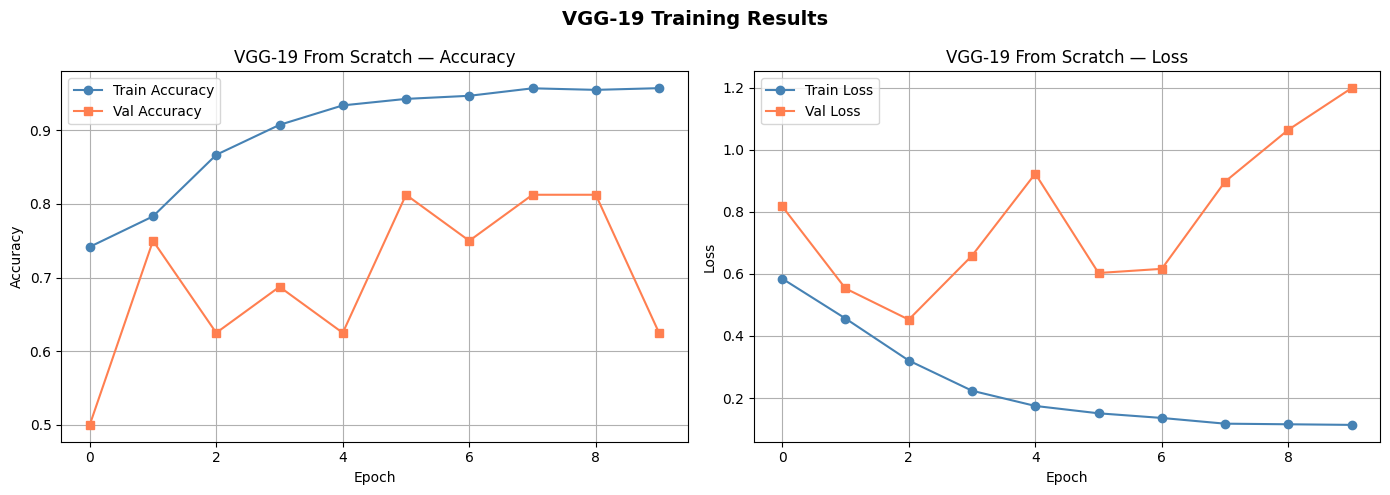

Plot saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], marker='o', label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], marker='s', label='Val Accuracy', color='coral')
axes[0].set_title('VGG-19 From Scratch — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], marker='o', label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], marker='s', label='Val Loss', color='coral')
axes[1].set_title('VGG-19 From Scratch — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('VGG-19 Training Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vgg19_plots.png', dpi=150)
plt.show()
print("Plot saved!")

# **Evaluating On Test Set**

In [14]:
# Proper evaluation on the 624-image test set
test_loss, test_acc = vgg19.evaluate(test_data)
print(f"\nVGG-19 Test Accuracy: {test_acc:.4f}")
print(f"VGG-19 Test Loss:     {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 363ms/step - accuracy: 0.5432 - loss: 1.4093

VGG-19 Test Accuracy: 0.7676
VGG-19 Test Loss:     0.7357


# **Saving The Model**

In [ ]:
vgg19.save('vgg19_scratch.h5')
print("Model saved successfully!")

## Part 3: Discussion

### Role of Each Layer in VGG-19

**Input (224×224×3) :** Accepts RGB image. Standardized size ensures consistent input across all images. 

**Conv2D (3×3, ReLU) :** Extracts spatial features. Early layers detect edges and textures, deeper layers detect complex shapes and patterns. ReLU removes negative values, adding non-linearity. 

**MaxPooling2D (2×2, stride 2) :**  Reduces spatial dimensions by half after each block. Keeps the strongest feature activations and reduces computation. 

**Flatten :** Converts the final 3D feature map (7×7×512) into a 1D vector of 25,088 values so dense layers can process it. 

**Dense(4096, ReLU) × 2 :**  Learns high-level combinations of features. These two layers together hold ~119M of the model's 139M parameters. 

**Dropout(0.5) :**  Randomly disables 50% of neurons during training to prevent overfitting. Disabled during inference. 

**Dense(2, Softmax) :** Outputs a probability for each class (NORMAL, PNEUMONIA). The class with the highest probability is the prediction. 




### Why VGG-19 Uses Small (3×3) Filters

VGG-19 deliberately uses small 3×3 filters instead of larger ones like 5×5 or 7×7. The key reasons are:

1. **Same receptive field, fewer parameters:** Two stacked 3×3 layers see the same area of the image as one 5×5 layer, but use 18 parameters instead of 25. Three 3×3 layers equal one 7×7 layer using 27 vs 49 parameters.
   
2. **More non-linearity:** Each 3×3 layer has its own ReLU activation. So stacking three 3×3 layers applies ReLU three times vs once for a 7×7, making the model better at learning complex patterns.


3. **Deeper network:** Smaller filters allow more layers in the same memory budget, which leads to richer hierarchical feature learning.

# **Extra- Self Experiment** 

# **Importing Models**

In [26]:
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import pandas as pd

# **Defining Build Transfer and Evaluation Function For All Three Models**

In [27]:
# Helper: build any transfer learning model in one shot
def build_transfer_model(base, num_classes):
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs=base.input, outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# Helper: evaluate and print results
def evaluate_model(model, model_name):
    test_data.reset()
    preds = model.predict(test_data)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_data.classes
    class_names = list(test_data.class_indices.keys())

    print(f"\n========== {model_name} ==========")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {
        'Model':     model_name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'F1 Score':  round(f1_score(y_true, y_pred, average='weighted'), 4)
    }

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 564ms/step - accuracy: 0.8151 - loss: 0.4188 - val_accuracy: 0.6250 - val_loss: 0.8925
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 561ms/step - accuracy: 0.9251 - loss: 0.1931 - val_accuracy: 0.7500 - val_loss: 0.5186
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 558ms/step - accuracy: 0.9381 - loss: 0.1745 - val_accuracy: 0.7500 - val_loss: 0.4458
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 557ms/step - accuracy: 0.9380 - loss: 0.1634 - val_accuracy: 0.7500 - val_loss: 0.4649
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 565ms/step - accuracy: 0.9420 - loss: 0.1469 - val_accuracy: 0.7500 - val_loss: 0.5538
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 244ms/step

========== VGG16 ==========
              precision    recall  f1-score   support

      NORMAL       0.95      0.74      0.83       234
   PNEUMONIA       0.86      0.98      0.91       390

    accuracy                           0.89       624
   macro av

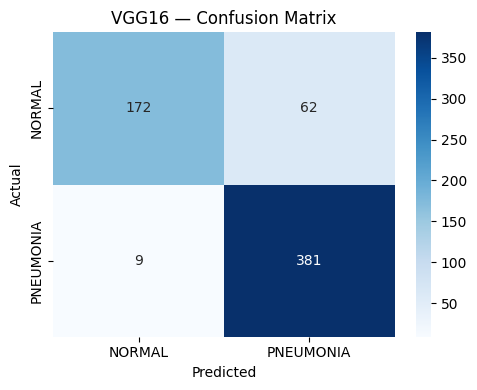

In [28]:
# Model 1: VGG16
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_vgg16 = build_transfer_model(vgg16_base, NUM_CLASSES)
history_vgg16 = model_vgg16.fit(train_data, epochs=5, validation_data=val_data)
result_vgg16 = evaluate_model(model_vgg16, 'VGG16')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 573ms/step - accuracy: 0.6832 - loss: 0.7203 - val_accuracy: 0.5625 - val_loss: 0.6841
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 539ms/step - accuracy: 0.7805 - loss: 0.4640 - val_accuracy: 0.5625 - val_loss: 0.7371
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 87s 536ms/step - accuracy: 0.7978 - loss: 0.4227 - val_accuracy: 0.5625 - val_loss: 0.9104
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 540ms/step - accuracy: 0.8065 - loss: 0.3912 - val_accuracy: 0.6250 - val_loss: 0.7859
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 541ms/step - accuracy: 0.8108 - loss: 0.3840 - val_accuracy: 0.6250 - val_loss: 0.8979
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 391ms/step

========== ResNet50 ==========
              precision    recall  f1-score   support

      NORMAL       0.78      0.39      0.52       234
   PNEUMONIA       0.72      0.94      0.81       390

    accuracy                           0.73       624
   mac

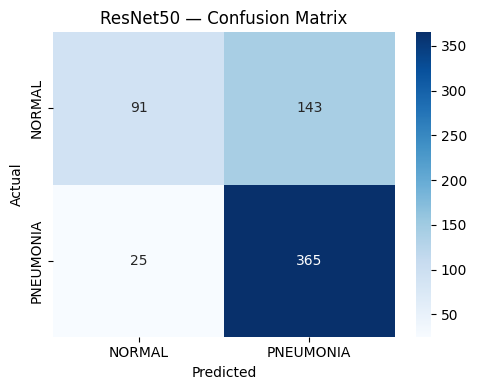

In [29]:
# Model 2: ResNet50
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_resnet = build_transfer_model(resnet_base, NUM_CLASSES)
history_resnet = model_resnet.fit(train_data, epochs=5, validation_data=val_data)
result_resnet = evaluate_model(model_resnet, 'ResNet50')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 581ms/step - accuracy: 0.8528 - loss: 0.3678 - val_accuracy: 0.8750 - val_loss: 0.2283
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 87s 532ms/step - accuracy: 0.9617 - loss: 0.1015 - val_accuracy: 0.9375 - val_loss: 0.1934
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 540ms/step - accuracy: 0.9635 - loss: 0.0970 - val_accuracy: 0.8125 - val_loss: 0.3374
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 87s 535ms/step - accuracy: 0.9637 - loss: 0.0863 - val_accuracy: 1.0000 - val_loss: 0.1653
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 538ms/step - accuracy: 0.9747 - loss: 0.0700 - val_accuracy: 0.8125 - val_loss: 0.3540
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 440ms/step

========== MobileNetV2 ==========
              precision    recall  f1-score   support

      NORMAL       0.97      0.65      0.78       234
   PNEUMONIA       0.83      0.99      0.90       390

    accuracy                           0.86       624
   ma

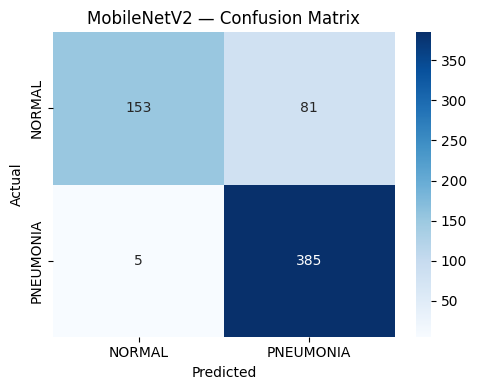

In [30]:
# Model 3: MobileNetV2
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_mobilenet = build_transfer_model(mobilenet_base, NUM_CLASSES)
history_mobilenet = model_mobilenet.fit(train_data, epochs=5, validation_data=val_data)
result_mobilenet = evaluate_model(model_mobilenet, 'MobileNetV2')

# **Comparison Among Models**


===== FINAL COMPARISON =====
             Accuracy  F1 Score
Model                          
VGG16          0.8862    0.8826
ResNet50       0.7308    0.7031
MobileNetV2    0.8622    0.8549


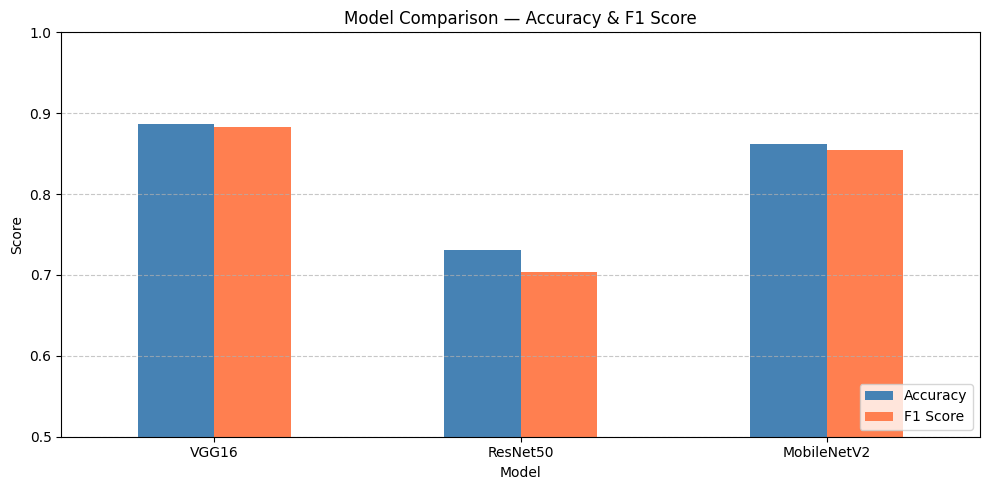

In [31]:
# Summary table
results = pd.DataFrame([result_vgg16, result_resnet, result_mobilenet])
results = results.set_index('Model')
print("\n===== FINAL COMPARISON =====")
print(results)

# Bar chart
results.plot(kind='bar', figsize=(10, 5), ylim=(0.5, 1.0), color=['steelblue', 'coral'])
plt.title('Model Comparison — Accuracy & F1 Score')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# **Which Model Performed The Best And Why?**


**Based on the results I got, here VGG16 performed the best with 88.62% accuracy and an F1 score of 0.88, followed by MobileNetV2 at 86.22% and ResNet50 at 73.08%. VGG16 won because its simple, uniform architecture of stacked 3×3 convolutions is naturally good at detecting texture differences in chest X-rays like cloudy vs clear lungs. Its pretrained ImageNet weights also transferred cleanly to medical images, allowing it to adapt quickly with just 5 epochs.**


**ResNet50 performed the worst not because it is a bad model, but because its architecture requires more epochs and fine-tuning to properly adapt to a new image domain 5 epochs simply was not enough for it. MobileNetV2 came in second place, which is impressive considering it is the lightest and smallest model of the three. Overall, for this specific dataset and training setup, VGG16 struck the best balance between model complexity and transfer learning efficiency.**